In [2]:
from typing import Optional
from dotenv import load_dotenv
load_dotenv()
import openpyxl
import os
import pandas as pd
import logging as logger
from azure.core.credentials import AzureKeyCredential
from openai import AzureOpenAI, OpenAI
from app.utils.azure_ai_search_retriever import AzureAISearchRetriever, SearchCredential
from app.utils.rag_orchestrator import RAGOrchestrator
from typing import List
import base64
import openai
import weave
import re 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

logger.getLogger().setLevel(logger.WARN)


In [4]:

def create_search_credential() -> SearchCredential:
    """Creates the appropriate Azure Search credential based on environment variables."""
    api_key = os.getenv("AZURE_SEARCH_API_KEY")
    if api_key:
        logger.info("Using Azure Search API Key credential.")
        return AzureKeyCredential(api_key)


def create_openai_client(purpose: str = "embedding") -> Optional[AzureOpenAI | OpenAI]:
    """Creates an AzureOpenAI client instance based on environment variables."""
    if purpose == "embedding":
        endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
        api_key = os.getenv("AZURE_OPENAI_API_KEY")
        api_version = os.getenv("AZURE_OPENAI_API_VERSION")
        log_prefix = "Embedding"
    elif purpose == "chat":
        endpoint = None
        api_version = None
        api_key = os.getenv("AZURE_OPENAI_CHAT_API_KEY", os.getenv("AZURE_OPENAI_API_KEY"))
        log_prefix = "Chat"
    else:
        raise ValueError(f"Invalid purpose for OpenAI client: {purpose}")

    try:
        if endpoint is None or api_version is None:
            client = OpenAI(
                api_key=api_key,
            )
        else:
            client = AzureOpenAI(
                azure_endpoint=endpoint,
                api_key=api_key,
                api_version=api_version,
            )
        # Perform a simple test if needed (e.g., list models), but might add latency
        logger.info(
            f"Azure OpenAI client for {log_prefix} initialized successfully (Endpoint: {endpoint}, API Version: {api_version}).")
        return client
    except Exception as e:
        logger.error(f"Failed to initialize Azure OpenAI {log_prefix} client: {e}", exc_info=True)
        return None  # Return None instead of raising, allow graceful failure if only one part is needed

def encode_file(file_path):
    with open(file_path, "rb") as file:
        return base64.b64encode(file.read()).decode('utf-8')


In [5]:
# --- Azure Search Configuration ---
search_service_name = os.getenv("AZURE_SEARCH_SERVICE_NAME")
index_name = os.getenv("AZURE_SEARCH_INDEX_NAME")
search_dns_suffix = os.getenv("AZURE_SEARCH_DNS_SUFFIX", "search.windows.net")

if not search_service_name or not index_name:
    raise ValueError("Missing required environment variables: AZURE_SEARCH_SERVICE_NAME and AZURE_SEARCH_INDEX_NAME")

search_service_endpoint = f"https://{search_service_name}.{search_dns_suffix}"
search_credential = create_search_credential()  # Handles API key, SPN, DefaultAzureCredential

# --- Azure OpenAI Configuration ---
# Embedding Client (Optional for Retriever if only doing text search)
openai_embedding_client = create_openai_client(purpose="embedding")
openai_embedding_deployment = os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT")

# Chat Client (Required for Orchestrator)
openai_chat_client = create_openai_client(purpose="chat")
openai_chat_deployment = os.getenv("AZURE_OPENAI_CHAT_DEPLOYMENT")

if not openai_chat_client or not openai_chat_deployment:
    raise ValueError(
        "Azure OpenAI Chat client configuration (Endpoint, Key, Version, Deployment) is required and incomplete.")

In [6]:
# --- Instantiate Retriever ---
retriever = AzureAISearchRetriever(
    search_service_endpoint=search_service_endpoint,
    index_name=index_name,
    search_credential=search_credential,
    openai_client=openai_embedding_client,  # Pass the client instance
    openai_embedding_deployment=openai_embedding_deployment  # Pass the deployment name
    # select_fields=None, # Use default
    # embedding_dimension=1536 # Use default
)
logger.info("AzureAISearchRetriever instantiated.")

# --- Instantiate Orchestrator ---
orchestrator = RAGOrchestrator(
    retriever=retriever,
    chat_client=openai_chat_client,  # Pass the client instance
    chat_deployment=openai_chat_deployment  # Pass the deployment name
    # system_prompt="Your custom system prompt here", # Optional
    # context_template="Source: {source}\nContent: {content}\n---\n", # Optional
)
logger.info("RAGOrchestrator instantiated.")

In [7]:
# --- Example Query ---
user_query = "Why do we need to do Business Process Re-engineering as a part of implementing an HIS/EHR? Note: Your answer must be in your own words."
logger.info(f"Answering query: '{user_query}'")

answer, sources = orchestrator.answer_query(
    user_query=user_query,
    top_k_retrieval=3,
    search_type="hybrid",  # Try hybrid search
    use_semantic_ranking=False  # Set to True if configured and desired
)

if answer:
    print("\n--- Answer ---")
    print(answer)
    print("\n--- Sources ---")
    if sources:
        for source in sources:
            print(f"- {source}")
    else:
        print("No sources were cited (or retrieval failed).")
else:
    print("\nFailed to get an answer.")

2025-04-02 00:55:52,298 - ERROR - Azure OpenAI API error during embedding generation: 404 - Error code: 404 - {'error': {'code': '404', 'message': 'Resource not found'}}
Traceback (most recent call last):
  File "c:\Users\MHS\Desktop\PROJECTS\ml-bu-autograder\app\utils\azure_ai_search_retriever.py", line 136, in _generate_embeddings
    response = self.openai_client.embeddings.create(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MHS\Desktop\PROJECTS\ml-bu-autograder\venv\Lib\site-packages\openai\resources\embeddings.py", line 128, in create
    return self._post(
           ^^^^^^^^^^^
  File "c:\Users\MHS\Desktop\PROJECTS\ml-bu-autograder\venv\Lib\site-packages\openai\_base_client.py", line 1242, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_cls))
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MHS\Desktop\PROJECTS\ml-bu-autograder\venv\Lib\site-pack


--- Answer ---
I couldn't find any relevant documents to answer your question.

--- Sources ---
No sources were cited (or retrieval failed).


## Load Google Drive Files
Since our datasets live in Google Drive, we connect to our data source. This particular method assumes you have [Drive for Desktop](https://dl.google.com/drive-file-stream/GoogleDriveSetup.exe) installed on your computer and you are accessing a local path. For this POC, we focus on assignment 2.

In [8]:
class StudentResponse:
    rubric_path: str
    submission_path: str
    def __init__(self, rubric_path, submission_path):
        self.rubric_path = rubric_path
        self.submission_path = submission_path

In [9]:
import os

# Check if the directory exists and list its contents

base_dir = r"G:\My Drive\met_data\Quiz_1\24sprgmetcs581_o1 Quiz 1.xlsx"
if os.path.exists(base_dir):
    print("✅ Path exists!")
    print("Contents:", os.listdir(base_dir))  # List files/folders inside
else:
    print("❌ Path does NOT exist!")


✅ Path exists!


NotADirectoryError: [WinError 267] The directory name is invalid: 'G:\\My Drive\\met_data\\Quiz_1\\24sprgmetcs581_o1 Quiz 1.xlsx'

In [10]:
# Initialize list to hold student responses
student_responses: List[StudentResponse] = []
# Relevant material list
relevant_material = r"G:\My Drive\met_data\Assignment 2 – EHR Functional Requirements Worksheet\CS581 Assignment 2 HIS Clinical (EHR) Functional Requirements 2025 Spring 1.pdf"
assignment_requirements = r"G:\My Drive\met_data\Assignment 2 – EHR Functional Requirements Worksheet\CS581 Assignment 2 HIS Clinical (EHR) Functional Requirements 2025 Spring 1.pdf"

In [11]:
# Define the base directory
base_dir = r"G:\My Drive\met_data\Assignment 2 – EHR Functional Requirements Worksheet\24fallmetcs581_m1 submissions and rubrics"
# Iterate through student directories
for student_number in os.listdir(base_dir):
    student_path = os.path.join(base_dir, student_number)

    if os.path.isdir(student_path):  # Ensure it's a directory
        rubric_path = os.path.join(student_path, "rubric.docx")
        submission_path = os.path.join(student_path, "submission.pptx")

        # Check if both expected files exist
        if os.path.exists(rubric_path) and os.path.exists(submission_path):
            student_responses.append(StudentResponse(rubric_path=rubric_path, submission_path=submission_path))

In [12]:
response = openai_chat_client.responses.create(
    model="gpt-4o",
    input=[
        {
            "role": "system",
            "content": [
                {
                    "type": "input_text",
                    "text": "Please analyze the attached file."
                }
            ]
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "input_file",
                    "filename": os.path.basename(relevant_material),
                    "file_data": f"data:application/pdf;base64,{encode_file(relevant_material)}"
                }
            ]
        }
    ],
    text={
        "format": {
            "type": "text"
        }
    },
    reasoning={},
    tools=[],
    temperature=1,
    max_output_tokens=2048,
    top_p=1,
    store=True
)


In [13]:
from IPython.display import Markdown, display
display(Markdown(response.output[0].content[0].text))

The document describes an assignment for developing high-level EHR functional requirements for Virginia Women’s Center (VWC). Here is a summary:

### Task Overview
- **Objective**: Create a high-level EHR Functional Requirements document for VWC.
- **Focus**: Clinical (EHR) functions of a Health Information System (HIS).

### Requirements
1. **Review**:
   - VWC case study's EHR functional requirements.
   - CMS Medicare MIPS Quality Payment Program's Promoting Interoperability requirements for 2024.

2. **Spreadsheet**:
   - Use the provided Microsoft Excel Functional Requirements spreadsheet.
   - Identify top 10-12 functions needed for VWC and PI requirements.
   - Rate each function's importance on a scale of 1-4.
   - Provide notes explaining the importance rating.

3. **Submission**:
   - Submit via Blackboard in Excel or Google Sheets format, naming the file with lastname_firstname Assignment 2.

### Importance Scale
- **4**: Essential
- **3**: Important
- **2**: Nice
- **1**: Optional

### Scoring (Vendor Score is not needed for this assignment)
- **4**: Fully fulfills with flexibility
- **3**: Fulfills well with less flexibility
- **2**: Basic fulfillment
- **1**: Partial fulfillment
- **0**: No capability

### Grading Criteria
- Understanding and importance of EHR functions (45 points)
- Importance and relevance of functions to VWC and government goals (45 points)
- Clarity, citations, and documentation (10 points)

Total: 100 points

The objective is to assess the relationship between key functions and the VWC’s needs, as well as alignment with governmental criteria.


Test out with prompt technique to observe the varied results


In [14]:
response = openai_chat_client.responses.create(
    model="gpt-4o",
    input=[
        {
            "role": "system",
            "content": [
                {
                    "type": "input_text",
                    "text": """You are an expert document analyst. Analyze the attached file and provide a structured response with:  
                    1. A brief summary (5-7 sentences).  
                    2. The top 3 key insights.  
                    3. Any contradictions, biases, or missing information.  
                    4. Recommendations for improvement (if applicable).  
                    Format your response clearly with headings."""
                }
            ]
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "input_file",
                    "filename": os.path.basename(relevant_material),
                    "file_data": f"data:application/pdf;base64,{encode_file(relevant_material)}"
                }
            ]
        }
    ],
    text={"format": {"type": "text"}},
    reasoning={},
    tools=[],
    temperature=0.5,
    max_output_tokens=1500,
    top_p=0.9,
    store=True
)


In [15]:
from IPython.display import Markdown, display
display(Markdown(response.output[0].content[0].text))

## Summary

The document outlines an assignment for a course titled CS581, focusing on developing a high-level Electronic Health Record (EHR) Functional Requirements document for the Virginia Women’s Center (VWC). The assignment requires students to identify and evaluate critical functions necessary for implementing an EHR system, with a focus on clinical functions. Students are instructed to review the VWC case study and the CMS Medicare MIPS Quality Payment Program's current Promoting Interoperability (PI) requirements. They must use a provided Excel spreadsheet to list the top 10-12 functions needed to meet VWC’s needs and PI requirements, assigning importance scores and justifying their choices. The assignment is graded based on understanding, identification, and relevance of functions, as well as clarity and quality of the submission.

## Key Insights

1. **Focus on Clinical Functions**: The assignment emphasizes identifying clinical functions crucial for the EHR system, aligning with the needs of VWC and government interoperability goals.
   
2. **Evaluation Criteria**: Students must rate the importance of each function on a scale from 1 to 4 and justify their ratings, ensuring a structured approach to assessing EHR requirements.

3. **Grading Rubric**: The assignment is graded on understanding of EHR functional requirements, identification and relevance of key functions, and clarity and quality of the material, with a total of 100 points available.

## Contradictions, Biases, or Missing Information

- **Lack of Specific Context**: The document lacks detailed context about the specific needs and current capabilities of VWC, which could impact the evaluation of functional requirements.
- **Bias Towards Government Requirements**: The assignment heavily emphasizes meeting government interoperability requirements, which may overshadow other organizational-specific needs.
- **No Vendor Evaluation**: The assignment explicitly excludes vendor evaluation, which could be crucial for understanding the practical implementation of the identified functions.

## Recommendations for Improvement

1. **Include Contextual Information**: Providing more background on VWC’s current systems and specific challenges would help students make more informed decisions.
   
2. **Balance Requirements**: Encourage consideration of both government requirements and VWC-specific needs to create a more balanced EHR requirements document.

3. **Incorporate Vendor Evaluation**: Including a component for evaluating potential vendors could enhance the practical applicability of the assignment.

Ingested Quiz 2 to showcase Prompt Enginnering techniques

In [16]:
excel = pd.read_excel(r'G:\My Drive\met_data\Quiz_2\24fallmetcs581_m1 Quiz 2.xlsx', sheet_name=None)
for sheet_name, df_sheet in excel.items():
    var_name = f"df_{sheet_name.replace(' ', '_')}"
    globals()[var_name] = df_sheet
    print(f"Assigned DataFrame to: {var_name}")


Assigned DataFrame to: df_Question_Details
Assigned DataFrame to: df_Student_Submissions


In [17]:
df_Student_Quiz_Responses = pd.read_excel(r'G:\My Drive\met_data\Quiz_2\24fallmetcs581_m1 Quiz 2.xlsx', sheet_name='Student Submissions')

In [18]:


#Convert the dates to the score, as it is meant to be in a score
def convert_datetime_to_score(datetime_str):
    return f"{int(datetime_str[5:7])}/{int(datetime_str[8:10])}" if datetime_str.startswith("2025") else datetime_str



In [19]:
df_Student_Quiz_Responses['question 11 score'] = df_Student_Quiz_Responses['question 11 score'].astype(str)
df_Student_Quiz_Responses['question 11 score'] = df_Student_Quiz_Responses['question 11 score'].str.replace(' ', '')
df_Student_Quiz_Responses['question 11 score'] = df_Student_Quiz_Responses['question 11 score'].apply(lambda x: convert_datetime_to_score(x).strip())

In [20]:
df_Student_Quiz_Responses

,Unnamed: 0,question 11 answer,question 11 score,question 11 feedback,question 12 answer,question 12 score,question 12 feedback,additional feedback
0,Student 1,claims management is one of the functionalitie...,14/15,You highlighted how claims management improves...,privacy and security is always a challenge whe...,2025-12-15 00:00:00,"Your statement of ""Hacking and breaching of da...",NaN
1,Student 2,One of the challenges for an HIS/EHR to suppor...,15/15,Excellent work identifying a key challenge and...,One function of a revenue cycle management sys...,15/15,Nice work!,NaN
2,Student 3,Claims management is a vital component of a re...,15/15,Nice work!,Data interoperability is a major obstacle for ...,15/15,Excellent work!,NaN
3,Student 4,One of the main challenges for an HIS/EHR to e...,15/15,Great work!,One function of a revenue cycle management sys...,15/15,Excellent work!,NaN
4,Student 5,A vital function of a revenue cycle management...,15/15,Excellent work! \n\n\n\n\nReminder if you use ...,One significant challenge for a Health Informa...,14/15,"Overall, good work! Including specific example...",NaN
5,Student 6,"As often discussed in class, data privacy and ...",15/15,Excellent work and leveraging details from oth...,One function of the Revenue Cycle Management (...,15/15,Your response effectively describes how stream...,NaN
6,Student 7,\t\nI think that one of the main challenges fo...,13/15,Your response effectively discusses the comple...,One function of RCM that can increase a care p...,15/15,NaN,NaN
7,Student 8,One function of Revenue Cycle Management that ...,15/15,Good work!,One major challenge in HIS/EHR to support popu...,13/15,Your explanation discusses how resistance to c...,NaN
8,Student 9,I think that a big challenge for HIS/EHR suppo...,13/15,Your response effectively highlights the chall...,Revenue Cycle Management (RCM) systems increas...,15/15,Good work!,NaN
9,Student 10,Interoperability is one of the challenges for ...,13/15,Your response highlights how the lack of inter...,One of the function about revenue cycle manage...,15/15,Good work!,NaN


Let's scale the leniency of the model 

First from 1 to 5 in terms of leniency to strictness, we begin observing to see if the model will grade based on that parameter. First, we will begin experimenting it with the quiz 2 responses, specifically question, and we will be given a course material, which is sample answer rubric 
CS581 2025 Spring 1 Quiz 2 (Pop Health & RCM) Short Answer Grading Rubric

First let's try level 1, which is lenient 

# Level 1 Leniency Grading

In [21]:
def grade_student_response(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)
    
    # Create the grading prompt
    grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 1 (Lenient)
You will grade the student's response with **a lenient approach**, focusing on encouraging learning rather than strict adherence to the material. This means:
- **Partial credit is given** even if the answer is incomplete but demonstrates understanding.
- **Minor mistakes** (e.g., wording, slight misinterpretations) are overlooked if the core idea is correct.
- **Constructive feedback is prioritized** over penalties, helping students refine their knowledge.

### Grading Criteria:
- **A score out of 15** reflecting the quality and completeness of the response.
- **Detailed feedback** for each criterion, emphasizing strengths and areas for improvement.
- **Gentle suggestions** for enhancement, guiding students toward better understanding.
- **Relevant supporting material** from the course content to justify feedback.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""
    
    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)


In [22]:
COURSE_MATERIAL = r"G:\My Drive\met_data\Quiz_2\CS581 2025 Spring 1 Quiz 2 (Pop Health & RCM) Short Answer Grading Rubric.docx"
# Grade each answer in the DataFrame
df_Student_Quiz_Responses["question 11 grade"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response(COURSE_MATERIAL, answer)
)


In [23]:
print(df_Student_Quiz_Responses["question 11 grade"])

0     ### Score: 13/15\n\n### Feedback:\n\n#### Iden...
1     ### Evaluation\n\n**Score: 14/15**\n\n---\n\n*...
2     ### Score: 14/15\n\n### Feedback:\n\n**Identif...
3     ### Evaluation\n\n**Score: 13/15**\n\n---\n\n*...
4     ### Score: 15/15\n\n#### Feedback:\n\n1. **Ide...
5     ### Evaluation of Student Response\n\n**Score:...
6     ### Score: 13/15\n\n#### Feedback:\n\n1. **Ide...
7     ### Score: 13/15\n\n#### Feedback:\n\n1. **Ide...
8     ### Score: 13/15\n\n#### Feedback:\n\n1. **Ide...
9     ### Evaluation\n\n**Score: 13/15**\n\n---\n\n*...
10    ### Evaluation\n\n**Score: 13/15**\n\n---\n\n*...
11    ## Evaluation of Student Response\n\n### Score...
12    ### Score: 12/15\n\n#### Feedback:\n\n1. **Ide...
13    ### Score: 13/15\n\n### Feedback:\n\n1. **Iden...
14    ### Score: 14/15\n\n### Feedback:\n\n#### Iden...
15    ### Score: 13/15\n\n#### Feedback:\n\n1. **Ide...
16    ### Score: 12/15\n\n### Feedback:\n\n#### Iden...
17    ### Score: 13/15\n\n### Feedback:\n\n**Ide

# Let's parse the grades from the AI text to 

In [24]:
#extract scores from the text
def extract_score(text):
    score = re.search(r"Score: (\d{1,2}/15)", text)
    if score:
        return score.group(1)
    return None

# Apply the function to each row in the 'question grade' column
df_Student_Quiz_Responses['AI Q11 grade lvl 1'] = df_Student_Quiz_Responses['question 11 grade'].apply(extract_score)

In [25]:
df_Student_Quiz_Responses

,Unnamed: 0,question 11 answer,question 11 score,question 11 feedback,question 12 answer,question 12 score,question 12 feedback,additional feedback,question 11 grade,AI Q11 grade lvl 1
0,Student 1,claims management is one of the functionalitie...,14/15,You highlighted how claims management improves...,privacy and security is always a challenge whe...,2025-12-15 00:00:00,"Your statement of ""Hacking and breaching of da...",NaN,### Score: 13/15\n\n### Feedback:\n\n#### Iden...,13/15
1,Student 2,One of the challenges for an HIS/EHR to suppor...,15/15,Excellent work identifying a key challenge and...,One function of a revenue cycle management sys...,15/15,Nice work!,NaN,### Evaluation\n\n**Score: 14/15**\n\n---\n\n*...,14/15
2,Student 3,Claims management is a vital component of a re...,15/15,Nice work!,Data interoperability is a major obstacle for ...,15/15,Excellent work!,NaN,### Score: 14/15\n\n### Feedback:\n\n**Identif...,14/15
3,Student 4,One of the main challenges for an HIS/EHR to e...,15/15,Great work!,One function of a revenue cycle management sys...,15/15,Excellent work!,NaN,### Evaluation\n\n**Score: 13/15**\n\n---\n\n*...,13/15
4,Student 5,A vital function of a revenue cycle management...,15/15,Excellent work! \n\n\n\n\nReminder if you use ...,One significant challenge for a Health Informa...,14/15,"Overall, good work! Including specific example...",NaN,### Score: 15/15\n\n#### Feedback:\n\n1. **Ide...,15/15
5,Student 6,"As often discussed in class, data privacy and ...",15/15,Excellent work and leveraging details from oth...,One function of the Revenue Cycle Management (...,15/15,Your response effectively describes how stream...,NaN,### Evaluation of Student Response\n\n**Score:...,13/15
6,Student 7,\t\nI think that one of the main challenges fo...,13/15,Your response effectively discusses the comple...,One function of RCM that can increase a care p...,15/15,NaN,NaN,### Score: 13/15\n\n#### Feedback:\n\n1. **Ide...,13/15
7,Student 8,One function of Revenue Cycle Management that ...,15/15,Good work!,One major challenge in HIS/EHR to support popu...,13/15,Your explanation discusses how resistance to c...,NaN,### Score: 13/15\n\n#### Feedback:\n\n1. **Ide...,13/15
8,Student 9,I think that a big challenge for HIS/EHR suppo...,13/15,Your response effectively highlights the chall...,Revenue Cycle Management (RCM) systems increas...,15/15,Good work!,NaN,### Score: 13/15\n\n#### Feedback:\n\n1. **Ide...,13/15
9,Student 10,Interoperability is one of the challenges for ...,13/15,Your response highlights how the lack of inter...,One of the function about revenue cycle manage...,15/15,Good work!,NaN,### Evaluation\n\n**Score: 13/15**\n\n---\n\n*...,13/15


## Let's visualize it!

First we check the distribution of grades for question 11 that were graded by the CA/TA

C:\Users\MHS\AppData\Local\Temp\ipykernel_15252\587413939.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


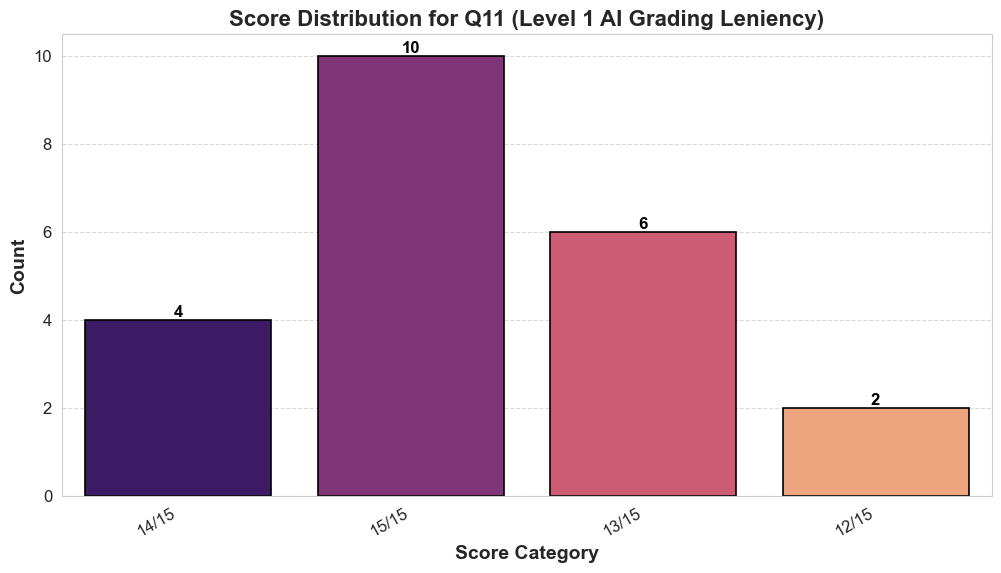

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses, 
    x='question 11 score', 
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 1 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


## Count Plot for Score Distribution for Q11 (Level 1 Leniency)

C:\Users\MHS\AppData\Local\Temp\ipykernel_15252\2721957284.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


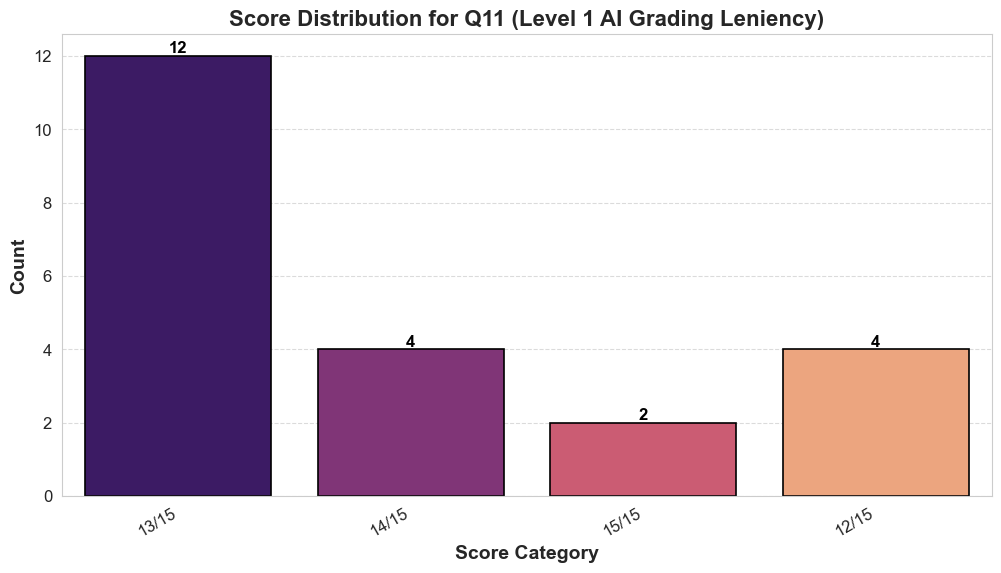

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses, 
    x='AI Q11 grade lvl 1', 
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 1 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


It was somewhat the same distribution as the CA/TA grading, mainly where a total of 22 students, 12 students had a 13/15 based on the rubric from the ai model, whereas 10 students had a 15/15, which were graded by CA/TA. We can check an overlay histogram to compare distribution between two grades

## Overlay Histogram to compare the distribution of the TA/CA grade to the AI grade of leniency level 1 (Lenient)

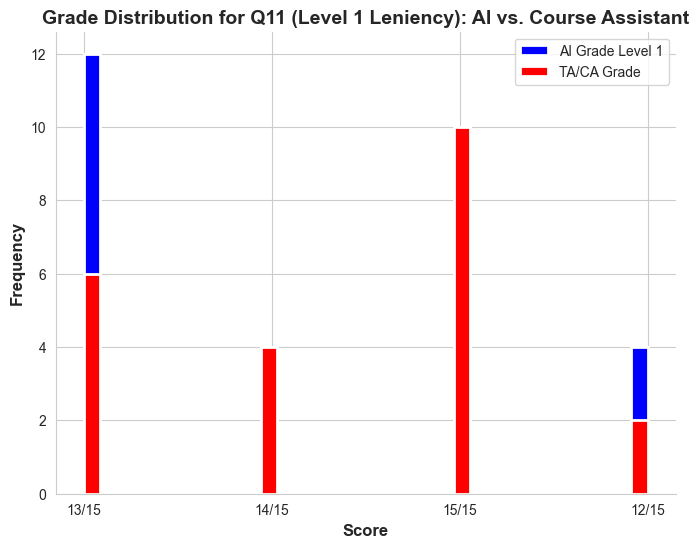

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(8, 6))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 1'], bins=35, linewidth=2, label='AI Grade Level 1', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='TA/CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 1 Leniency): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()


As stated, it seems the AI model is not as much lenient as the CA/TA, as most students received a 13/15 from AI model on leniency level of 1, whereas students scored a full credit (15/15), as they were graded by CA/TA

# Level 2 Leniency Grading 



In [29]:
def grade_student_response_lvl2(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)
    
    # Create the grading prompt
    grading_prompt = grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 2 (Slightly Lenient)
You will grade the student's response with a **slightly lenient approach**, balancing encouragement with accuracy. This means:
- **Partial credit is still given**, but responses should show clear understanding.
- **Minor mistakes are considered**, but they should not significantly affect comprehension.
- **Constructive feedback is provided**, but with slightly stricter adherence to key concepts.

### Grading Criteria:
- **A score out of 15** reflecting the quality and completeness of the response.
- **Feedback for each criterion**, highlighting strengths and pinpointing areas for improvement.
- **More specific suggestions** to correct misunderstandings while still encouraging the student.
- **Relevant quotes** from the course material to justify feedback and guide learning.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""

    
    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)


In [30]:
# Grade each answer in the DataFrame with Level 2 leniency
df_Student_Quiz_Responses["question 11 grade lvl 2"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response_lvl2(COURSE_MATERIAL, answer))

In [31]:
#extract scores from the text
def extract_score(text):
    score = re.search(r"Score: (\d{1,2}/15)", text)
    if score:
        return score.group(1)
    return None

# Apply the function to each row in the 'question grade' column
df_Student_Quiz_Responses['AI Q11 grade lvl 2'] = df_Student_Quiz_Responses['question 11 grade lvl 2'].apply(extract_score)

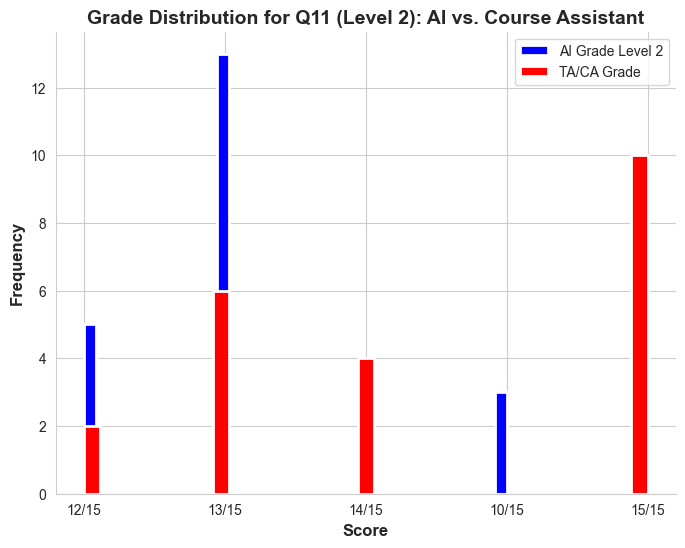

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(8, 6))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 2'], bins=35, linewidth=2, label='AI Grade Level 2', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='TA/CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 2): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()


We see that the model actually gave a 10/15 score to two anonymized students based on the quiz rubric. Compared to the TA/CA grading, where none of them gave a low score like the AI did. 

C:\Users\MHS\AppData\Local\Temp\ipykernel_15252\790910345.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


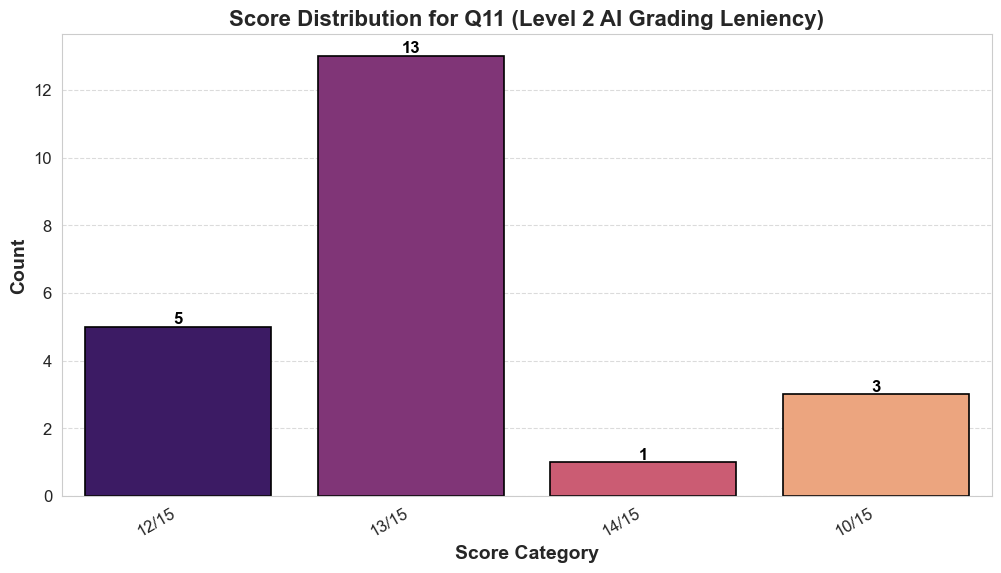

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses, 
    x='AI Q11 grade lvl 2', 
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 2 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


Now we are beginning to see students getting scores of 12/15 and 10/15 indicating that the AI was moderately lenient, avoiding extreme high or low scores. The majority of students scored 13/15. There are now three students with 10/15, whereas in the first level, it had none. Let's go a level higher.

# Level 3 Leniency Grading

Now let's try level three leniency grading 

In [34]:
def grade_student_response_lvl3(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)
    
    # Create the grading prompt
    grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 3 (Moderately Strict)
You will grade the student's response with a **moderately strict approach**, emphasizing accuracy and correctness. This means:
- **Partial credit** is still given, but responses must clearly demonstrate understanding of the core concepts.
- **Mistakes are noted and addressed** more thoroughly, and the student’s response must adhere more closely to the material.
- **Feedback is constructive but direct**, focusing on areas where the student needs improvement with specific recommendations for correction.

### Grading Criteria:
- **A score out of 15** reflecting the quality and completeness of the response, with a stronger emphasis on correctness.
- **Direct feedback for each criterion**, pointing out mistakes clearly and offering suggestions to correct misunderstandings.
- **Specific references** to the course material are provided to ensure the student knows where they went wrong and how to improve.
- **Concise but firm suggestions** for how to enhance the response, with less emphasis on encouragement compared to leniency levels 1 and 2.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""
    
    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)


In [35]:
df_Student_Quiz_Responses["question 11 grade lvl 3"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response_lvl3(COURSE_MATERIAL, answer))

In [36]:
df_Student_Quiz_Responses['AI Q11 grade lvl 3'] = df_Student_Quiz_Responses['question 11 grade lvl 3'].apply(extract_score)

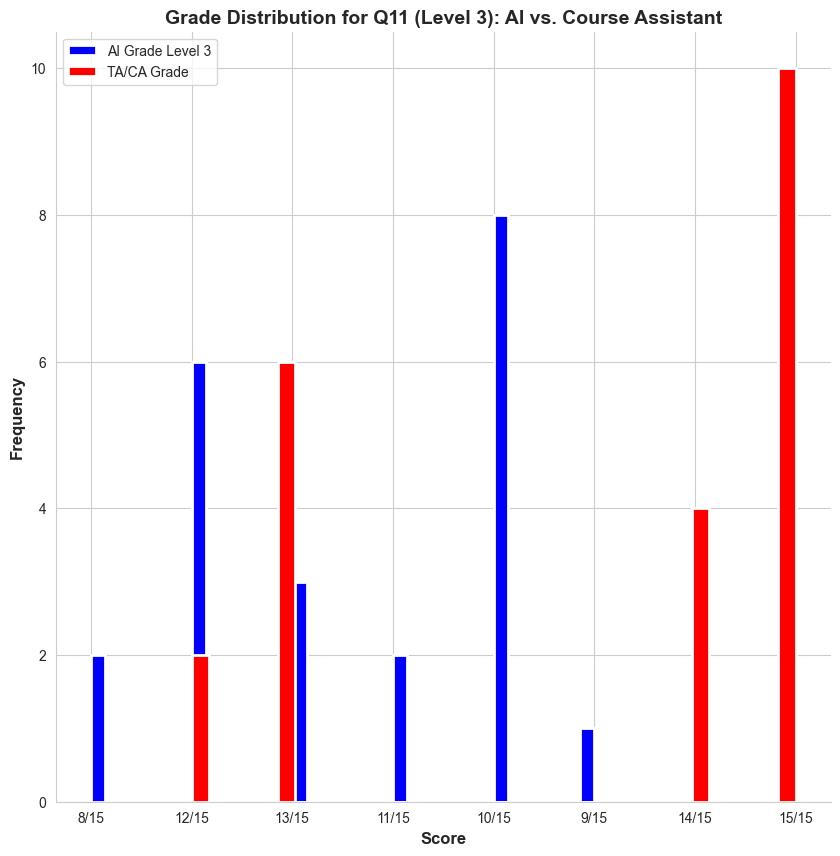

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(10, 10))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 3'], bins=35, linewidth=2, label='AI Grade Level 3', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='TA/CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 3): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()



Now we notice some somewhat average scores of 10/15 are from somewhat eight students in class, much lower than the previous test, which was only three. Also note that now there students given score of 9's and 8's from the AI model.

C:\Users\MHS\AppData\Local\Temp\ipykernel_15252\2661637868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


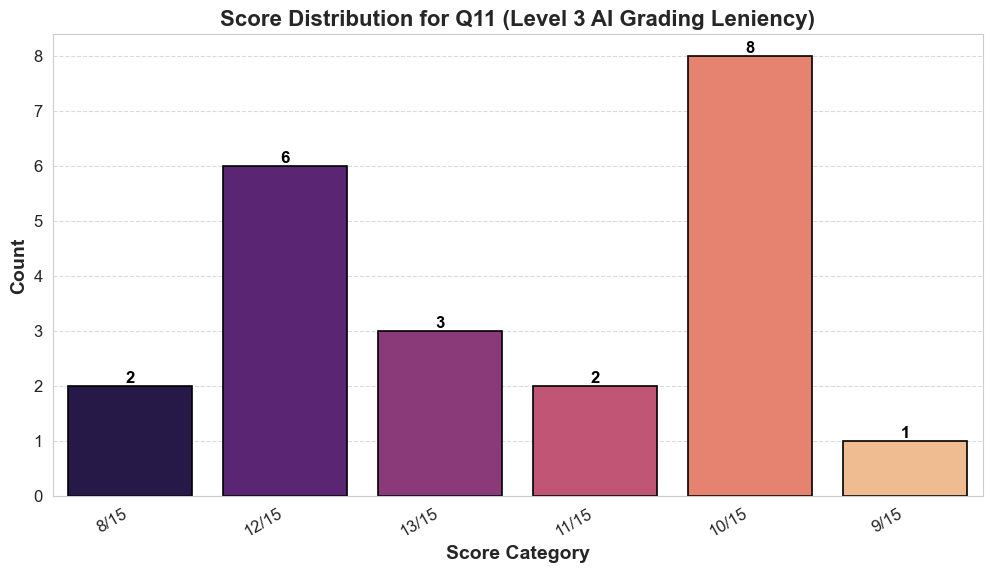

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses, 
    x='AI Q11 grade lvl 3', 
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 3 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


Now we are beginning to see harshness from the AI grader, no extremely high scores anymore. Eight students with a score of 10/15, which was the mode of the scores from the AI grader. 

# Level 4 Grading Leniency 

In [39]:
def grade_student_response_lvl4(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)
    
    # Create the grading prompt
    grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 4 (Strict)
You will grade the student's response with a **strict approach**, prioritizing accuracy, completeness, and adherence to the provided material. This means:
- **Partial credit is limited**, and responses must closely follow the course material.
- **Mistakes are thoroughly analyzed**, and even minor errors will result in deductions.
- **Feedback is firm and precise**, clearly identifying incorrect statements and gaps in understanding.
- **Higher expectations for completeness**—responses should cover all necessary details without vague or unsupported claims.

### Grading Criteria:
- **A score out of 15** with a strong emphasis on correctness and full alignment with the course material.
- **Thorough feedback for each criterion**, explicitly stating where the response falls short.
- **Exact references** to the course material, ensuring the student understands their mistakes.
- **Minimal leniency in grading**—responses must be well-structured, factually accurate, and demonstrate a deep understanding of the subject matter.
- **Strict but constructive recommendations** for improvement, guiding the student to meet high academic standards.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""

    
    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)


In [40]:
df_Student_Quiz_Responses["question 11 grade lvl 4"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response_lvl4(COURSE_MATERIAL, answer))

In [41]:
df_Student_Quiz_Responses['AI Q11 grade lvl 4'] = df_Student_Quiz_Responses['question 11 grade lvl 4'].apply(extract_score)

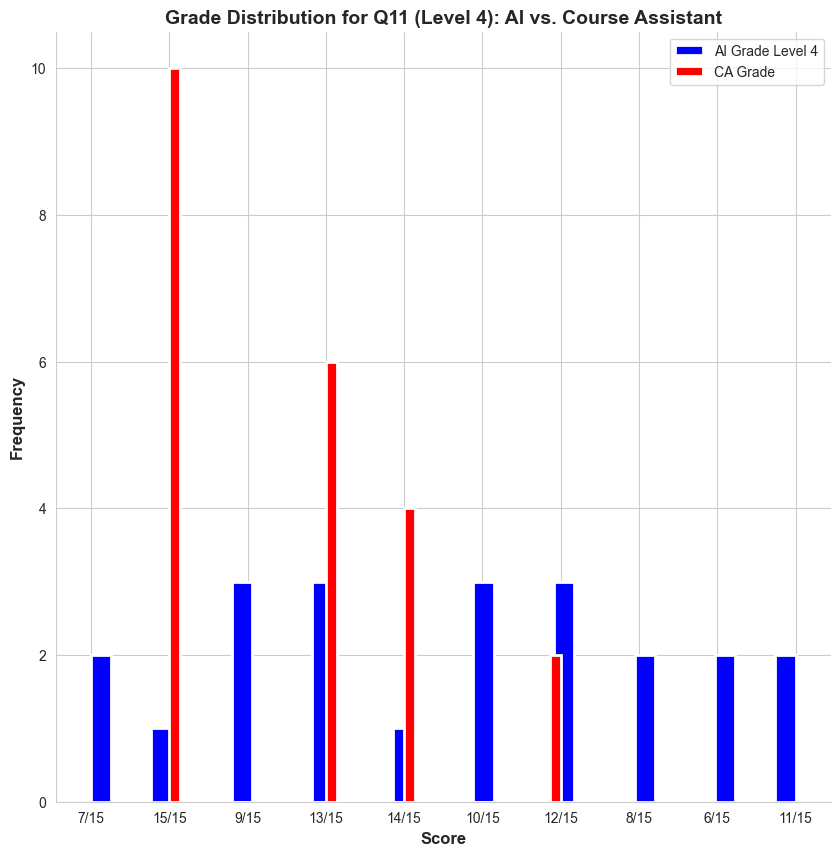

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(10, 10))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 4'], bins=35, linewidth=2, label='AI Grade Level 4', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 4): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()



The AI grader (blue bars) assigned a wide range of scores, with **10/15** being the most frequent. It also frequently gave **8/15, 12/15, and 9/15**, while lower scores like **6/15** and higher scores like **15/15** were less common. The AI tended to avoid extreme scores, distributing most grades in the mid-range. This suggests a more cautious grading approach, with fewer perfect or near-perfect scores.

C:\Users\MHS\AppData\Local\Temp\ipykernel_15252\371444310.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


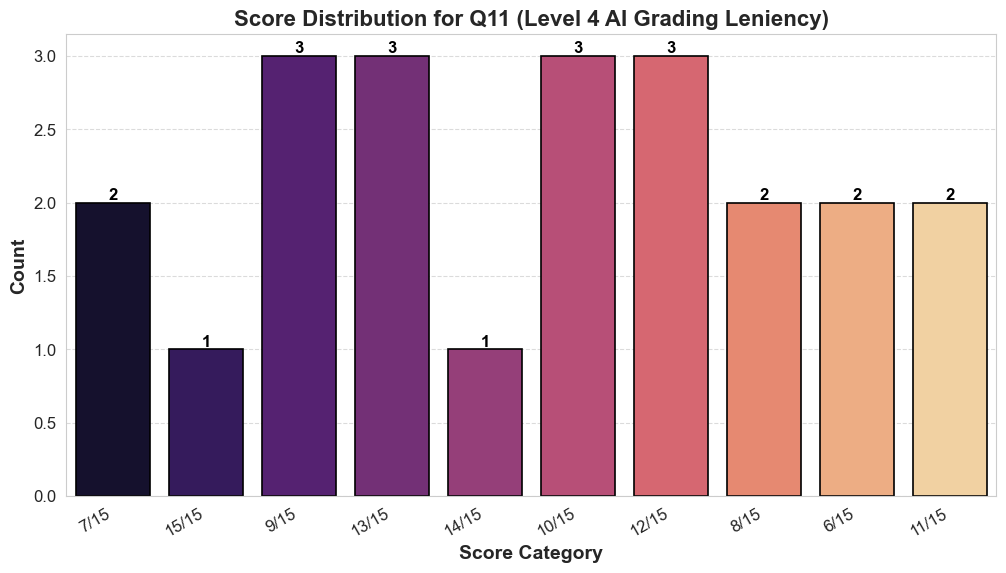

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses, 
    x='AI Q11 grade lvl 4', 
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 4 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


The graph shows the score distribution for Q11 under Level 4 AI Grading Leniency, with **10/15**, **9/15**, **13/15**, **12/15** being the most frequently assigned score (5 times). The AI grader also frequently gave **8/15 (2 times)** and **12/15 (3 times)**, while other scores appeared less often. Extreme scores like **15/15** and **14/15** were rare, suggesting a tendency toward mid-range grading. Comparing this with TA/CA grades would reveal if the AI is more lenient or stricter than human graders.

## Level 5 Grading Leniency

In [48]:
def grade_student_response_lvl5(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)
    
    # Create the grading prompt
    grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 5 (Very Strict)
You will grade the student's response with the **strictest possible approach**, requiring complete accuracy, depth, and direct alignment with the course material. This means:
- **No partial credit is given**—responses must be entirely correct and comprehensive.
- **Every mistake, even minor ones, results in a deduction** to ensure precision.
- **Feedback is firm and uncompromising**, directly pointing out any inaccuracies or omissions.
- **No room for vague, incomplete, or incorrect responses**—every statement must be supported by the course material.

### Grading Criteria:
- **A score out of 15**, with no leniency for partial understanding or minor errors.
- **In-depth feedback for each criterion**, identifying every error and explaining why it is incorrect.
- **Strict adherence to the course material**, requiring direct citations for every key concept.
- **Minimal subjective interpretation**—grading is purely based on factual correctness.
- **High expectations for structure, clarity, and precision**—responses must be well-organized and professionally written.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""


    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)



In [49]:

df_Student_Quiz_Responses["question 11 grade lvl 5"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response_lvl5(COURSE_MATERIAL, answer))

In [51]:
df_Student_Quiz_Responses['AI Q11 grade lvl 5'] = df_Student_Quiz_Responses['question 11 grade lvl 5'].apply(extract_score)

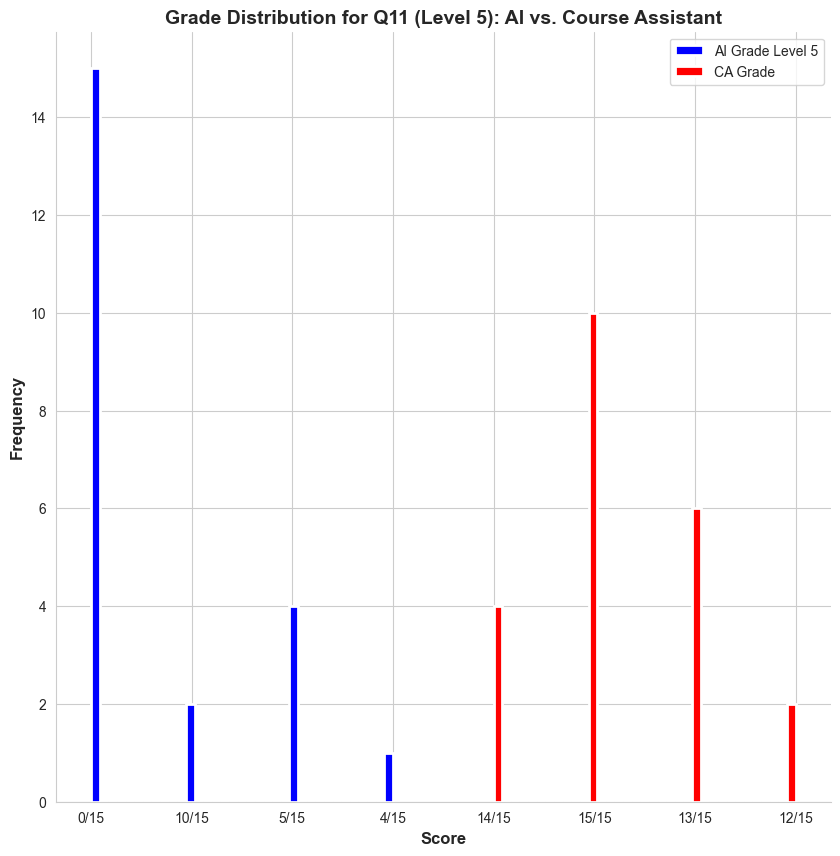

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(10, 10))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 5'], bins=35, linewidth=2, label='AI Grade Level 5', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 5): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()



The histogram shows the AI grader's scores (in blue) for Q11 at Level 5, ranging from 0/15 to 14/15, with no students receiving a perfect 15/15. The most frequent score is 0/15, with 16 students, indicating the AI grader was very strict or struggled to evaluate responses. The next most common score is 5/15, with a frequency of 4, followed by scores of 10/15 given to two students and 4/15 each given to only one student. This distribution suggests a highly skewed pattern, with a large cluster at the lowest score and a few students receiving higher scores.

C:\Users\MHS\AppData\Local\Temp\ipykernel_15252\2199518732.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


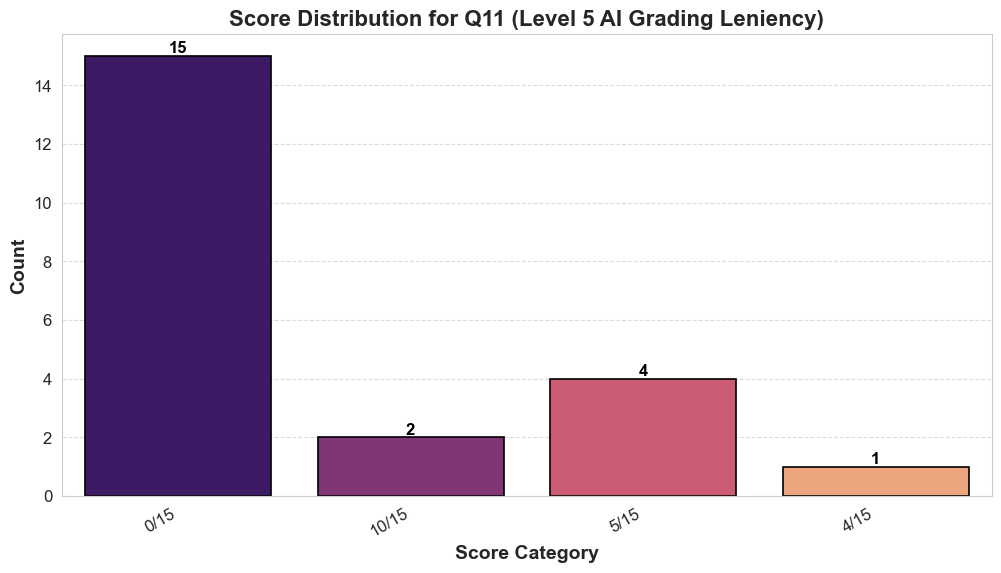

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses, 
    x='AI Q11 grade lvl 5', 
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 5 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


In this count plot, the AI grader graded a 0/15 the majority of the students. It seems that the model was seeking for the full and actual answer based on the rubric path. The highest scores was a 10/15, where two students recieved it. The AI model was very unforgiving based on the prompt. 

In [55]:
df_Student_Quiz_Responses.to_excel(r'C:\Users\MHS\Desktop\24fallmetcs581_m1 Quiz 2.xlsx', index=False)

#